# Explicación de predicciones para una Red Neuronal usando Random Forest

- Integrantes: Felipe Peralta, Samantha Suquilanda

## Carga de Librerías y Datos

In [4]:
import pandas as pd
import numpy as np
import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.utils import class_weight
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
import lime
import lime.lime_tabular
from sklearn.tree import plot_tree

In [5]:
df = pd.read_csv('../data/online+shoppers+purchasing+intention+dataset/online_shoppers_intention.csv')

## Análisis Exploratorio de Datos

In [6]:
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

In [7]:
print(f"Dimensiones del dataset: {df.shape}")
print("Tipos de datos y nulos:")
print(df.info())

Dimensiones del dataset: (12330, 18)
Tipos de datos y nulos:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12330 entries, 0 to 12329
Data columns (total 18 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Administrative           12330 non-null  int64  
 1   Administrative_Duration  12330 non-null  float64
 2   Informational            12330 non-null  int64  
 3   Informational_Duration   12330 non-null  float64
 4   ProductRelated           12330 non-null  int64  
 5   ProductRelated_Duration  12330 non-null  float64
 6   BounceRates              12330 non-null  float64
 7   ExitRates                12330 non-null  float64
 8   PageValues               12330 non-null  float64
 9   SpecialDay               12330 non-null  float64
 10  Month                    12330 non-null  object 
 11  OperatingSystems         12330 non-null  int64  
 12  Browser                  12330 non-null  int64  
 13  Region         

In [8]:
print("Estadísticas:")
display(df.describe())

Estadísticas:


,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,OperatingSystems,Browser,Region,TrafficType
count,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000
mean,2.315166,80.818611,0.503569,34.472398,31.731468,1194.746220,0.022191,0.043073,5.889258,0.061427,2.124006,2.357097,3.147364,4.069586
std,3.321784,176.779107,1.270156,140.749294,44.475503,1913.669288,0.048488,0.048597,18.568437,0.198917,0.911325,1.717277,2.401591,4.025169
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,1.000000
25%,0.000000,0.000000,0.000000,0.000000,7.000000,184.137500,0.000000,0.014286,0.000000,0.000000,2.000000,2.000000,1.000000,2.000000
50%,1.000000,7.500000,0.000000,0.000000,18.000000,598.936905,0.003112,0.025156,0.000000,0.000000,2.000000,2.000000,3.000000,2.000000
75%,4.000000,93.256250,0.000000,0.000000,38.000000,1464.157214,0.016813,0.050000,0.000000,0.000000,3.000000,2.000000,4.000000,4.000000
max,27.000000,3398.750000,24.000000,2549.375000,705.000000,63973.522230,0.200000,0.200000,361.763742,1.000000,8.000000,13.000000,9.000000,20.000000


In [9]:
# mirar nulos y duplicados
nulos = df.isnull().sum().sum()
duplicados = df.duplicated().sum()
print(f"Total de valores nulos: {nulos}")
print(f"Filas duplicadas: {duplicados}")

Total de valores nulos: 0
Filas duplicadas: 125


In [10]:
# borrar duplicados
df.drop_duplicates(inplace=True)

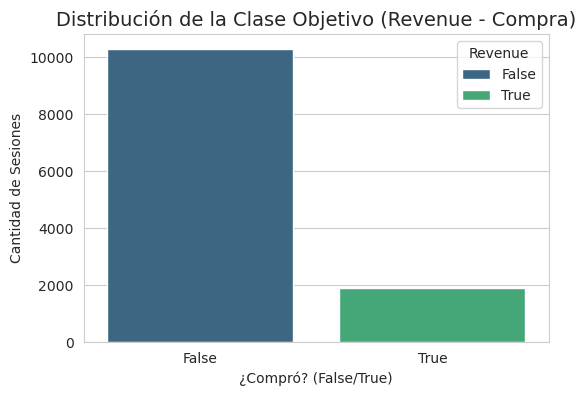

Compras: 15.63%
No Compras: 84.37%


In [11]:
plt.figure(figsize=(6, 4))
sns.countplot(x='Revenue', data=df, palette='viridis', hue='Revenue')
plt.title('Distribución de la Clase Objetivo (Revenue - Compra)', fontsize=14)
plt.xlabel('¿Compró? (False/True)')
plt.ylabel('Cantidad de Sesiones')
plt.show()

compra_ratio = df['Revenue'].value_counts(normalize=True)
print(f"Compras: {compra_ratio.iloc[1]*100:.2f}%")
print(f"No Compras: {compra_ratio.iloc[0]*100:.2f}%")

- El dataset está desbalanceado

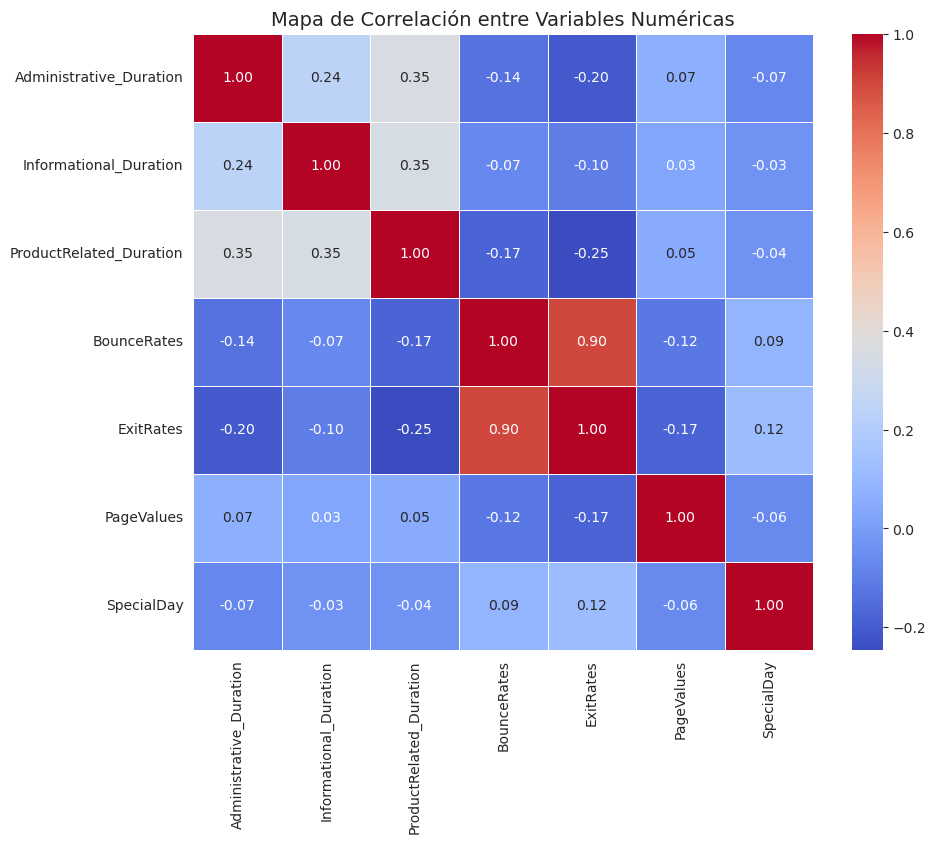

In [12]:
# Seleccionamos solo las columnas numéricas principales para el mapa de calor
cols_numericas = ['Administrative_Duration', 'Informational_Duration', 
                  'ProductRelated_Duration', 'BounceRates', 'ExitRates', 
                  'PageValues', 'SpecialDay']

plt.figure(figsize=(10, 8))
# Calculamos la correlación
corr_matrix = df[cols_numericas].corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Mapa de Correlación entre Variables Numéricas', fontsize=14)
plt.show()

- Alta correlación entre 'BounceRates' y 'ExitRates'

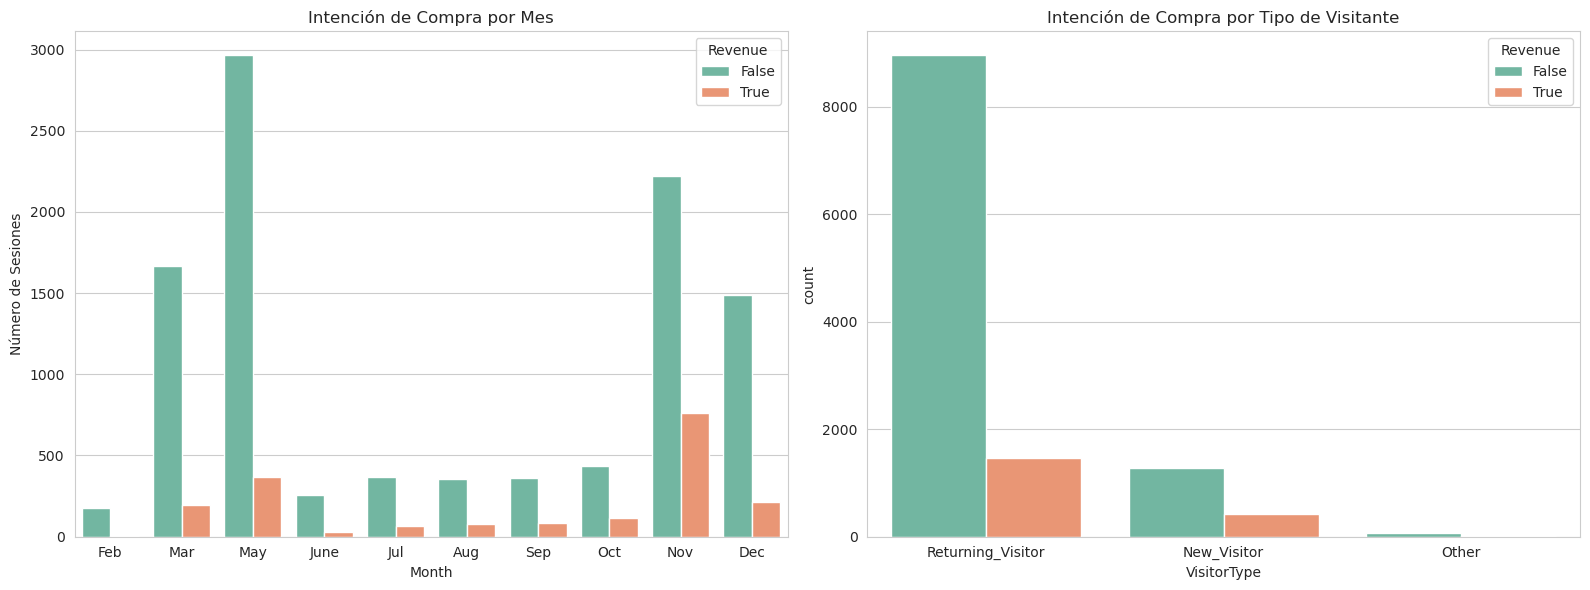

In [13]:
# analisis categorico con la variable objetivo
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Ventas por Mes
sns.countplot(x='Month', hue='Revenue', data=df, 
              order=['Feb', 'Mar', 'May', 'June', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'], 
              palette='Set2', ax=axes[0])
axes[0].set_title('Intención de Compra por Mes')
axes[0].set_ylabel('Número de Sesiones')

# Ventas por Tipo de Visitante
sns.countplot(x='VisitorType', hue='Revenue', data=df, palette='Set2', ax=axes[1])
axes[1].set_title('Intención de Compra por Tipo de Visitante')

plt.tight_layout()
plt.show()

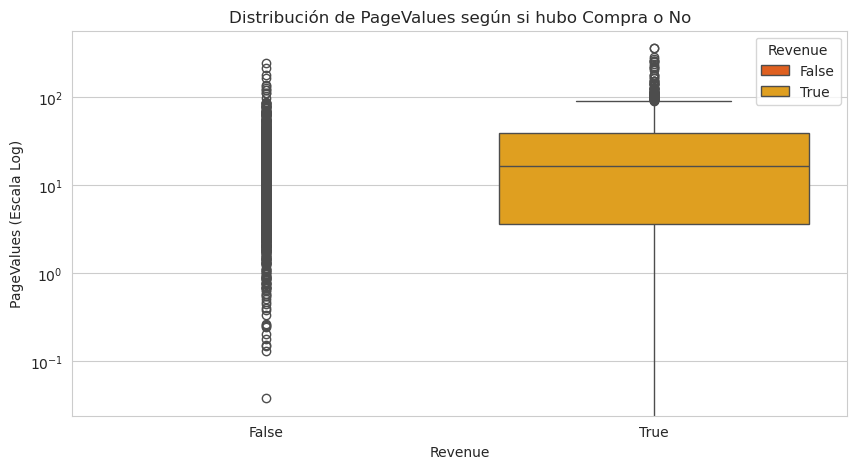

In [14]:
# detectar outliers en PageValues
plt.figure(figsize=(10, 5))
sns.boxplot(x='Revenue', y='PageValues', data=df, palette='autumn', hue='Revenue')
plt.title('Distribución de PageValues según si hubo Compra o No')
plt.yscale('log') # Escala logarítmica para ver mejor porque hay muchos ceros
plt.ylabel('PageValues (Escala Log)')
plt.show()

## Creación y Entrenamiento del Modelo de Red Neuronal Densa

In [15]:
# pre procesamiento de datos

# Convertir booleanos a 0 y 1
df['Weekend'] = df['Weekend'].astype(int)
df['Revenue'] = df['Revenue'].astype(int)

# Encoding de variables categóricas (Month, VisitorType) usando One-Hot Encoding
df_encoded = pd.get_dummies(df, columns=['Month', 'VisitorType'], drop_first=True)

# Separar Features (X) y Target (y)
X = df_encoded.drop('Revenue', axis=1)
y = df_encoded['Revenue']

# Convertir a flotantes
X = X.astype('float32')

# Dividir en Train y Test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# escalar los datos
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Convertir a tensores de TensorFlow
X_train_tensor = tf.convert_to_tensor(X_train_scaled, dtype=tf.float32)
X_test_tensor = tf.convert_to_tensor(X_test_scaled, dtype=tf.float32)
y_train_tensor = tf.convert_to_tensor(y_train.values, dtype=tf.float32)
y_test_tensor = tf.convert_to_tensor(y_test.values, dtype=tf.float32)

print(f"Forma de los datos de entrada: {X_train_tensor.shape}")

Forma de los datos de entrada: (9764, 26)


In [16]:
# crear y entrenar el modelo de red neuronal

model = Sequential([
    # Capa de entrada (tantas neuronas como columnas tengamos)
    Dense(64, activation='relu', input_shape=(X_train_tensor.shape[1],)),
    Dropout(0.2), # Para evitar overfitting
    
    Dense(32, activation='relu'),
    Dropout(0.2),
    
    Dense(16, activation='relu'),
    
    # Capa de salida (1 neurona con sigmoide porque es clasificación binaria: Compra SI/NO)
    Dense(1, activation='sigmoid')
])

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

In [17]:
# calcular los pesos basados en tus datos de entrenamiento
# Nota: y_train debe ser tu vector de etiquetas antes de convertirlo a tensor, 
# o puedes usar y_train.values si es una Serie de pandas.
class_weights = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train), 
    y=y_train
)

# Convertirlo a un diccionario para Keras
class_weights_dict = dict(enumerate(class_weights))

print(f"Pesos calculados: {class_weights_dict}")

Pesos calculados: {0: 0.5940618155268922, 1: 3.1578266494178524}


In [18]:
# entrenar el modelo
history = model.fit(
    X_train_tensor, 
    y_train_tensor,
    epochs=20,
    batch_size=32,
    validation_split=0.2,
    verbose=1,
    class_weight=class_weights_dict 
)

Epoch 1/20
245/245 [==============================] - 1s 2ms/step - loss: 0.5548 - accuracy: 0.6985 - val_loss: 0.4629 - val_accuracy: 0.7988
Epoch 2/20
245/245 [==============================] - 0s 1ms/step - loss: 0.4491 - accuracy: 0.7976 - val_loss: 0.3843 - val_accuracy: 0.8346
Epoch 3/20
245/245 [==============================] - 0s 1ms/step - loss: 0.4329 - accuracy: 0.8022 - val_loss: 0.3583 - val_accuracy: 0.8618
Epoch 4/20
245/245 [==============================] - 0s 1ms/step - loss: 0.4125 - accuracy: 0.8209 - val_loss: 0.3332 - val_accuracy: 0.8643
Epoch 5/20
245/245 [==============================] - 0s 1ms/step - loss: 0.3945 - accuracy: 0.8255 - val_loss: 0.3557 - val_accuracy: 0.8469
Epoch 6/20
245/245 [==============================] - 0s 1ms/step - loss: 0.3859 - accuracy: 0.8263 - val_loss: 0.3869 - val_accuracy: 0.8269
Epoch 7/20
245/245 [==============================] - 0s 2ms/step - loss: 0.3846 - accuracy: 0.8293 - val_loss: 0.3128 - val_accuracy: 0.8746
Epoch 

77/77 [==============================] - 0s 480us/step
Reporte de Clasificación
              precision    recall  f1-score   support

           0       0.94      0.93      0.94      2079
           1       0.63      0.67      0.65       362

    accuracy                           0.89      2441
   macro avg       0.78      0.80      0.79      2441
weighted avg       0.89      0.89      0.89      2441



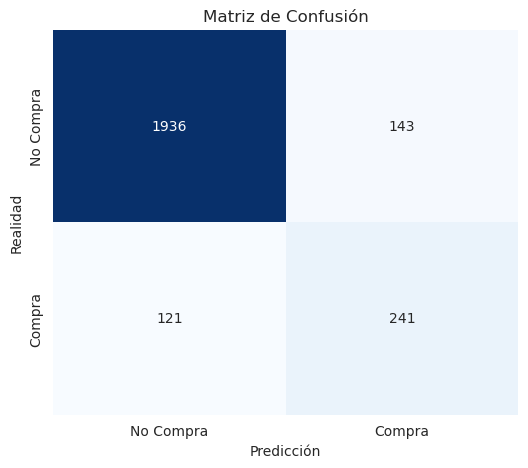

In [20]:
# obtener las predicciones crudas (probabilidades)
y_pred_probs = model.predict(X_test_tensor)

# convertir probabilidades a clases (0 o 1) usando un umbral de 0.7
y_pred = (y_pred_probs > 0.7).astype(int)

# imprimir el reporte completo
print("Reporte de Clasificación")
print(classification_report(y_test, y_pred))

# 4. Visualizar la Matriz de Confusión
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.xlabel('Predicción')
plt.ylabel('Realidad')
plt.title('Matriz de Confusión')
plt.xticks([0.5, 1.5], ['No Compra', 'Compra'])
plt.yticks([0.5, 1.5], ['No Compra', 'Compra'])
plt.show()

## Explicación de Predicciones con Random Forest

### Explicación Global

Reporte Random Forest
              precision    recall  f1-score   support

           0       0.92      0.97      0.94      2079
           1       0.75      0.51      0.60       362

    accuracy                           0.90      2441
   macro avg       0.83      0.74      0.77      2441
weighted avg       0.89      0.90      0.89      2441



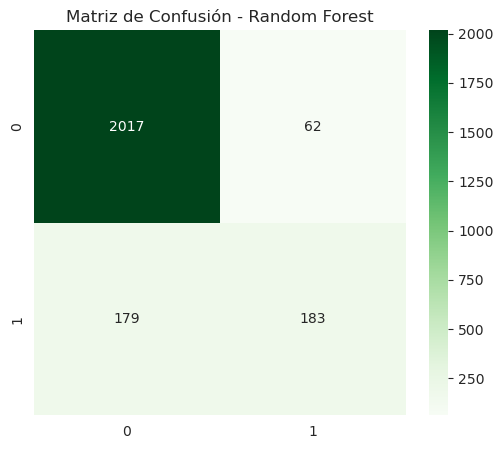

In [21]:
# 1. Configurar Random Forest con balanceo de clases
rf_model = RandomForestClassifier(n_estimators=100, 
                                  class_weight='balanced', 
                                  random_state=42,
                                  n_jobs=-1)

# 2. Entrenar
rf_model.fit(X_train, y_train)

# 3. Evaluar
y_pred_rf = rf_model.predict(X_test)

print("Reporte Random Forest")
print(classification_report(y_test, y_pred_rf))

# Matriz de Confusión
plt.figure(figsize=(6,5))
sns.heatmap(confusion_matrix(y_test, y_pred_rf), annot=True, fmt='d', cmap='Greens')
plt.title('Matriz de Confusión - Random Forest')
plt.show()

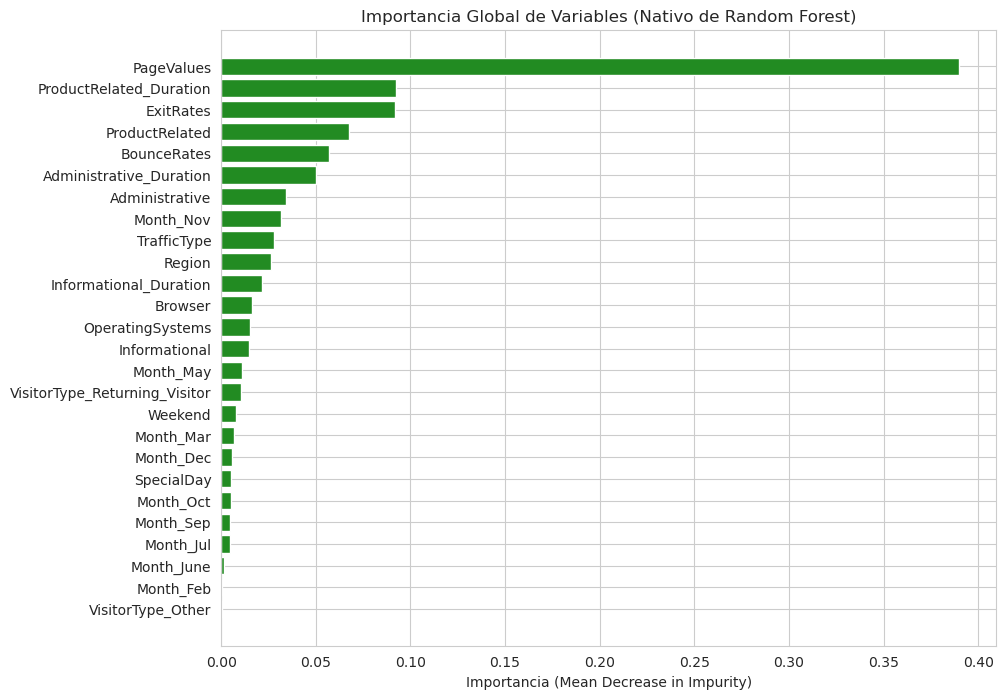

In [23]:
def graficar_importancia_rf(model, feature_names):
    # Extraer la importancia calculada durante el entrenamiento
    importances = model.feature_importances_
    
    # Crear DataFrame para ordenar
    feature_importance_df = pd.DataFrame({
        'Feature': feature_names,
        'Importance': importances
    })
    
    # Ordenar descendente
    feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=True)
    
    # Graficar
    plt.figure(figsize=(10, 8))
    plt.barh(feature_importance_df['Feature'], feature_importance_df['Importance'], color='forestgreen')
    plt.xlabel("Importancia (Mean Decrease in Impurity)")
    plt.title("Importancia Global de Variables (Nativo de Random Forest)")
    plt.show()

# Ejecutar
graficar_importancia_rf(rf_model, X.columns)

### Explicación individual

In [29]:
explainer_lime = lime.lime_tabular.LimeTabularExplainer(
    training_data=np.array(X_train),
    feature_names=X.columns,
    class_names=['No Compra', 'Compra'],
    mode='classification'
)

In [35]:
def explicar_cliente_lime(idx, model, X_test, y_test):
    # Convertir a numpy si es necesario
    if hasattr(X_test, 'values'):
        X_test_np = X_test.values
    else:
        X_test_np = X_test
        
    cliente_data = X_test.iloc[idx].values if hasattr(X_test, 'iloc') else X_test[idx]
    
    print(f"\nAnálisis Cliente #{idx} con LIME")
    
    # Obtener etiqueta real
    realidad = y_test.iloc[idx] if hasattr(y_test, 'iloc') else y_test[idx]
    print(f"Realidad: {'Compra' if realidad==1 else 'No Compra'}")
    
    # Crear función wrapper que mantenga los nombres de las características
    def predict_fn_wrapper(data):
        # Convertir numpy array a DataFrame con nombres de columnas
        if isinstance(data, np.ndarray):
            data = pd.DataFrame(data, columns=X.columns)
        return model.predict_proba(data)
    
    # Generar explicación usando el wrapper
    exp = explainer_lime.explain_instance(
        data_row=cliente_data, 
        predict_fn=predict_fn_wrapper,  # Usar el wrapper en lugar de model.predict_proba directamente
        num_features=10
    )
    
    fig = exp.as_pyplot_figure()
    plt.title(f"Explicación LIME - Cliente #{idx}")
    plt.tight_layout()
    plt.show()



Análisis Cliente #1 con LIME
Realidad: Compra


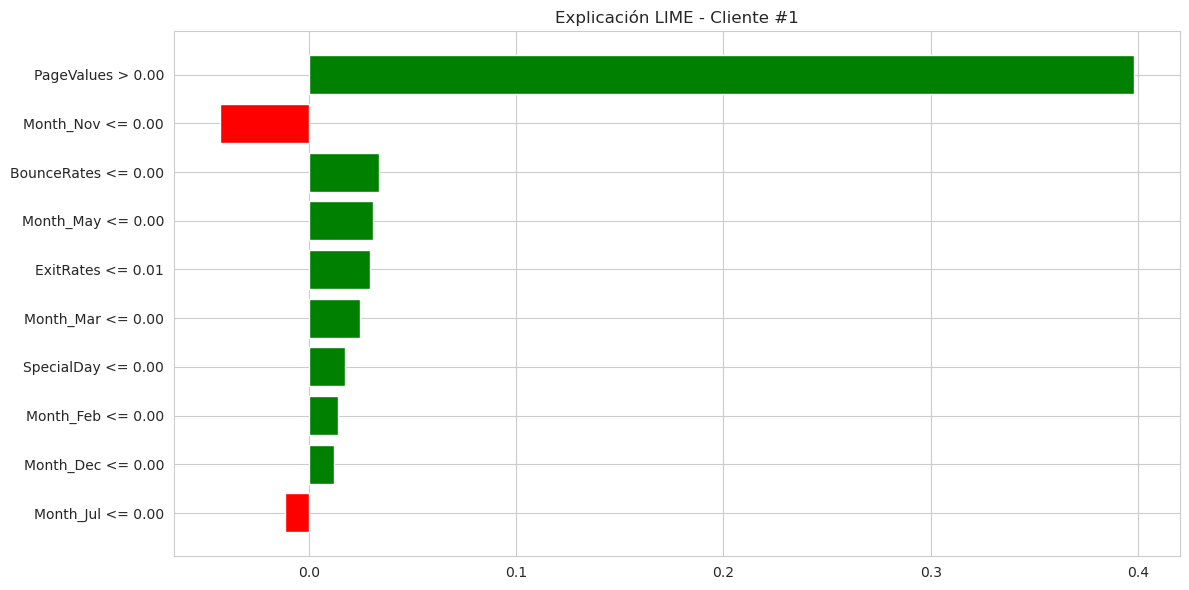

In [36]:
explicar_cliente_lime(1, rf_model, X_test, y_test)


Análisis Cliente #100 con LIME
Realidad: No Compra


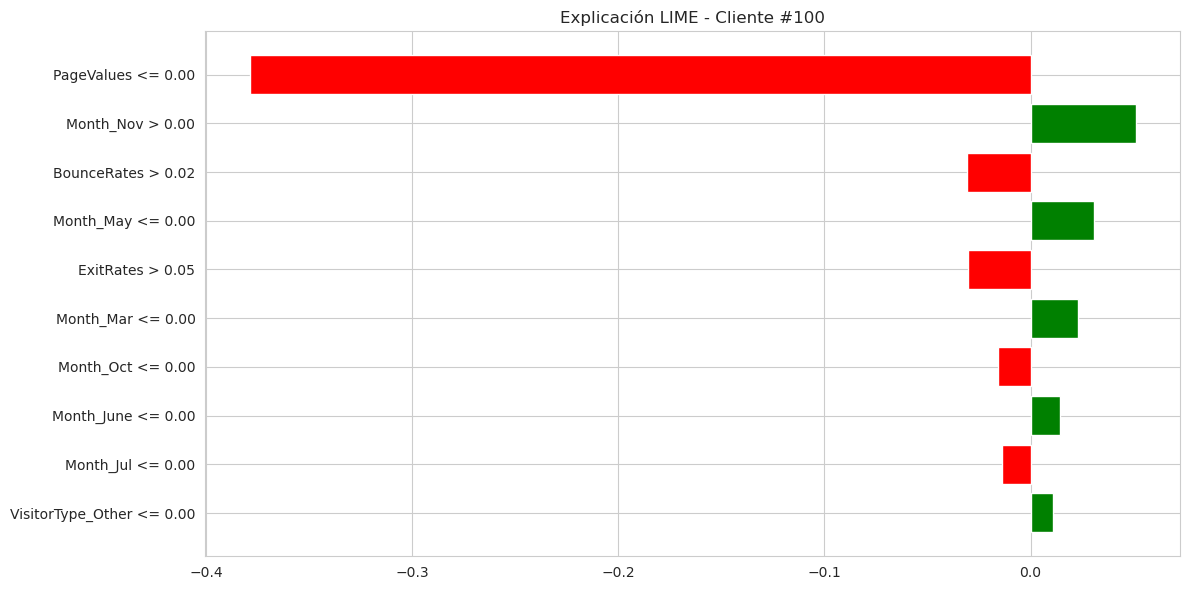

In [37]:
explicar_cliente_lime(100, rf_model, X_test, y_test)

In [41]:
def graficiar_arbol_decision_individual(rf_model, feature_names, tree_index=0, max_depth=3):
    # Configuración de la figura
    plt.figure(figsize=(20, 10), dpi=300)

    plot_tree(rf_model.estimators_[tree_index], 
            feature_names=feature_names,
            class_names=['No Compra', 'Compra'],
            filled=True,           
            rounded=True,          
            fontsize=10,           
            max_depth=max_depth)           # maxima profundidad para legibilidad

    plt.title("Visualización de un Árbol de Decisión Individual del Random Forest")
    plt.show()

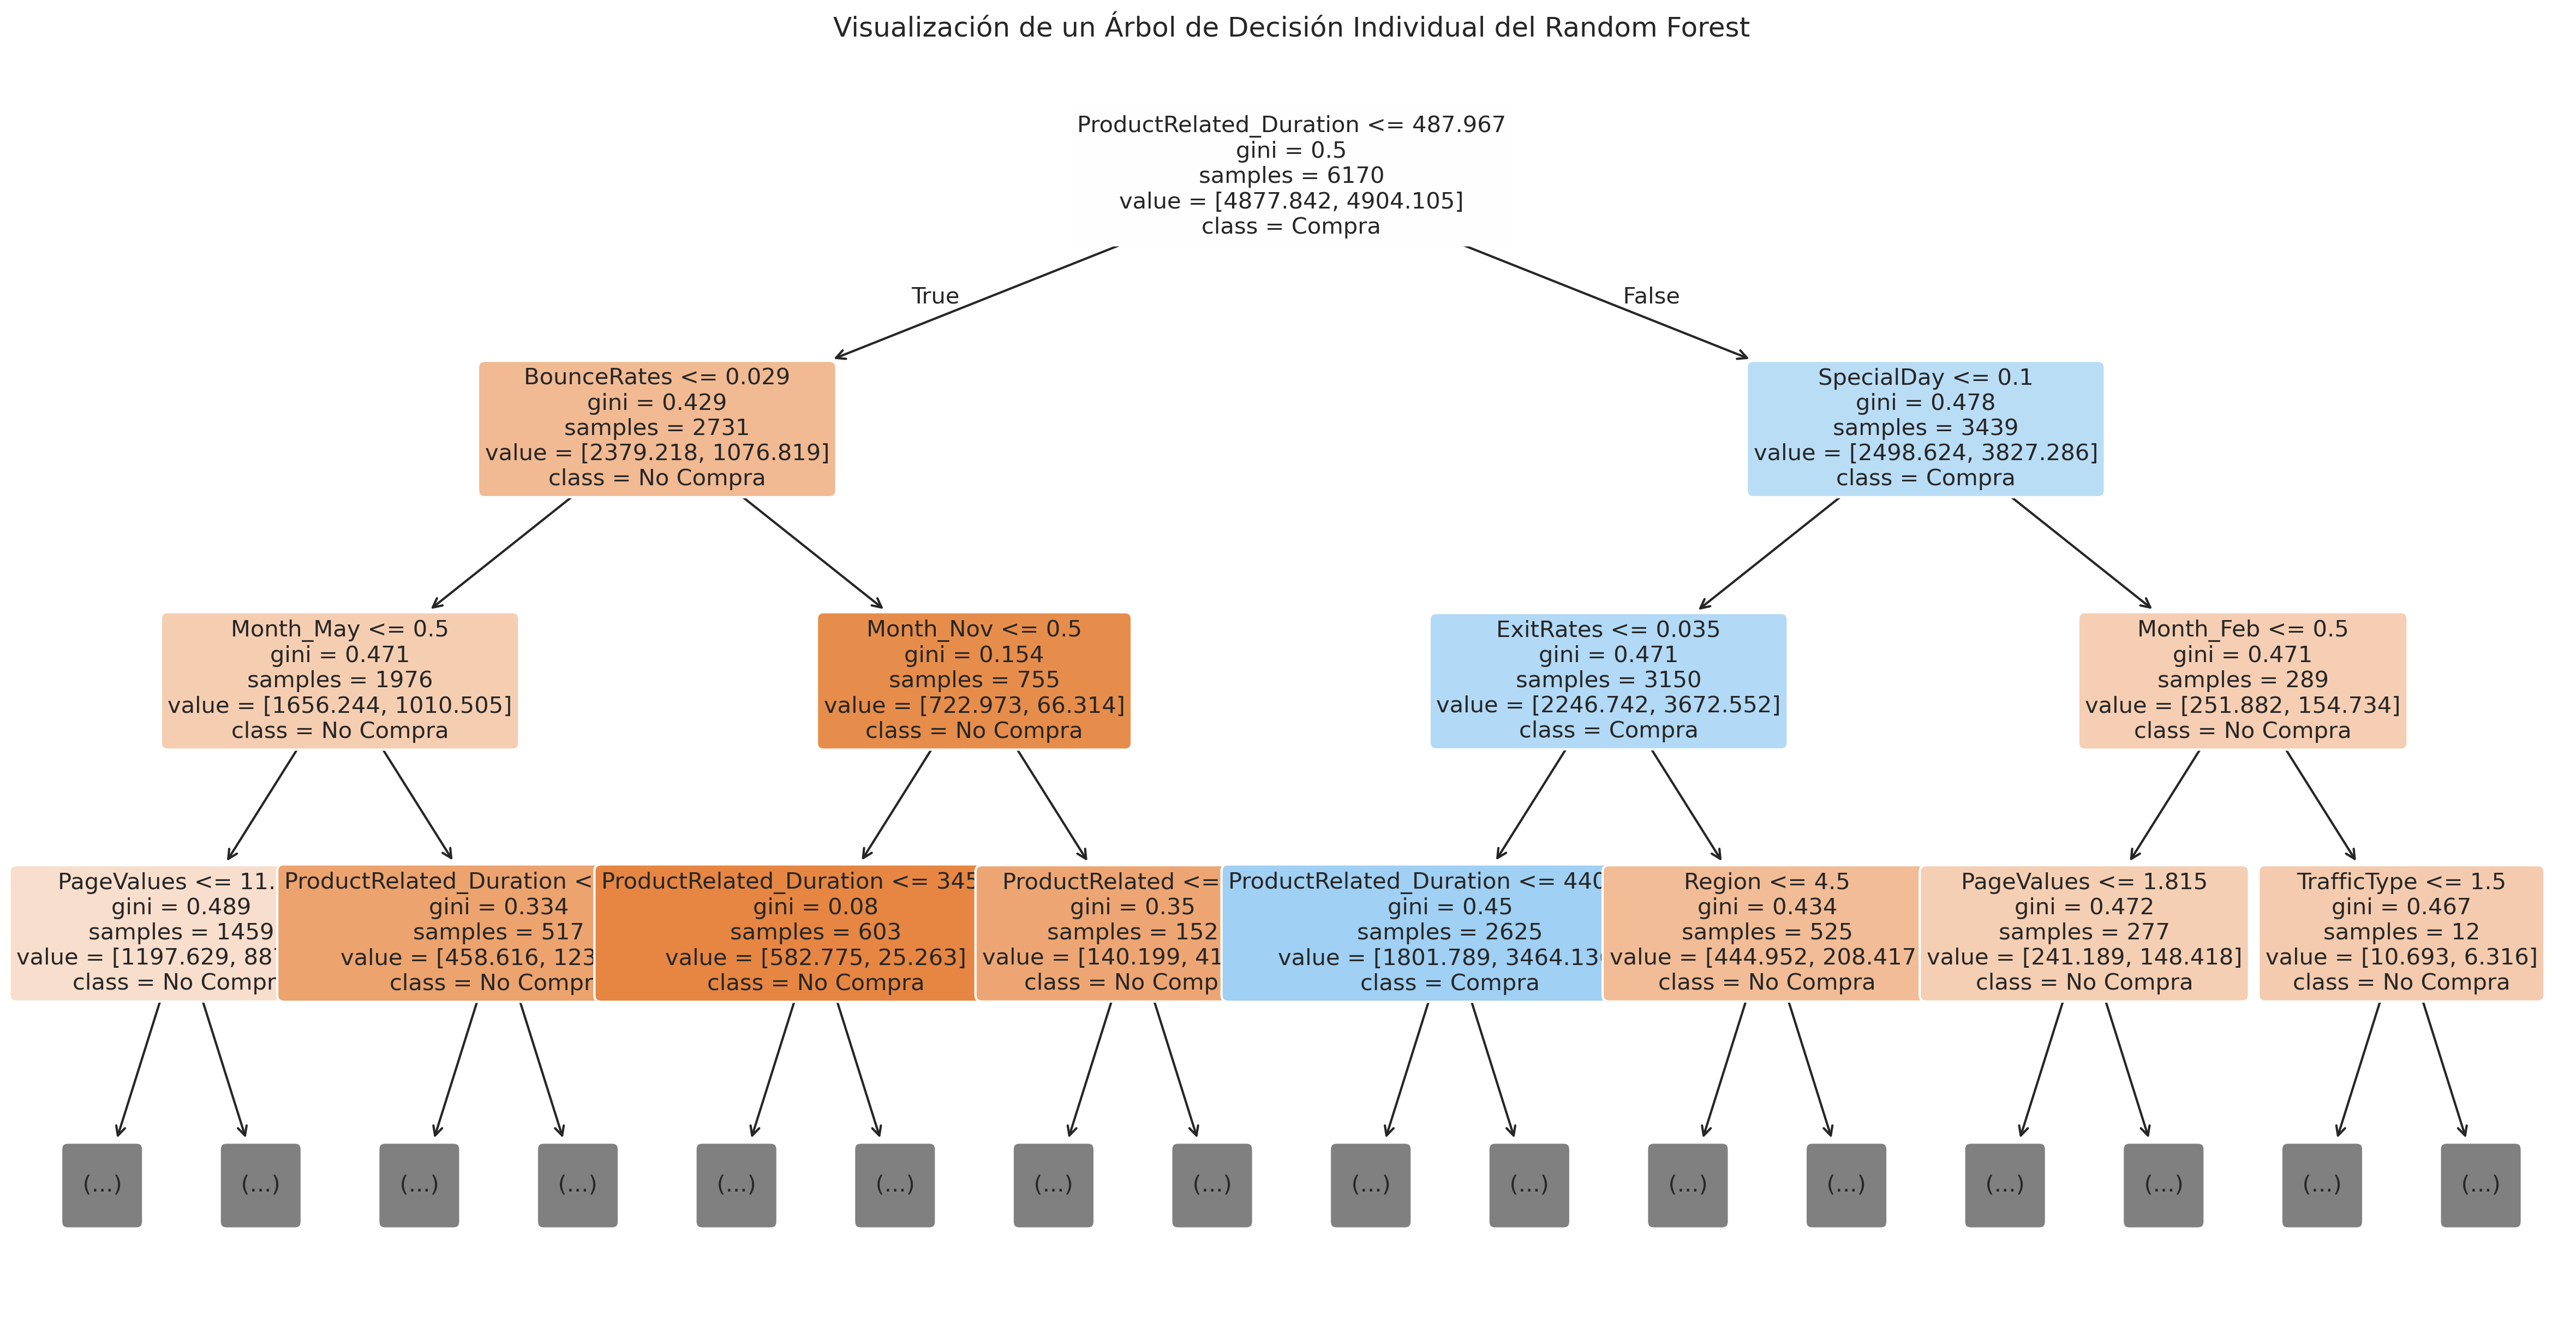

In [43]:
graficiar_arbol_decision_individual(rf_model, X.columns, tree_index=0, max_depth=3)

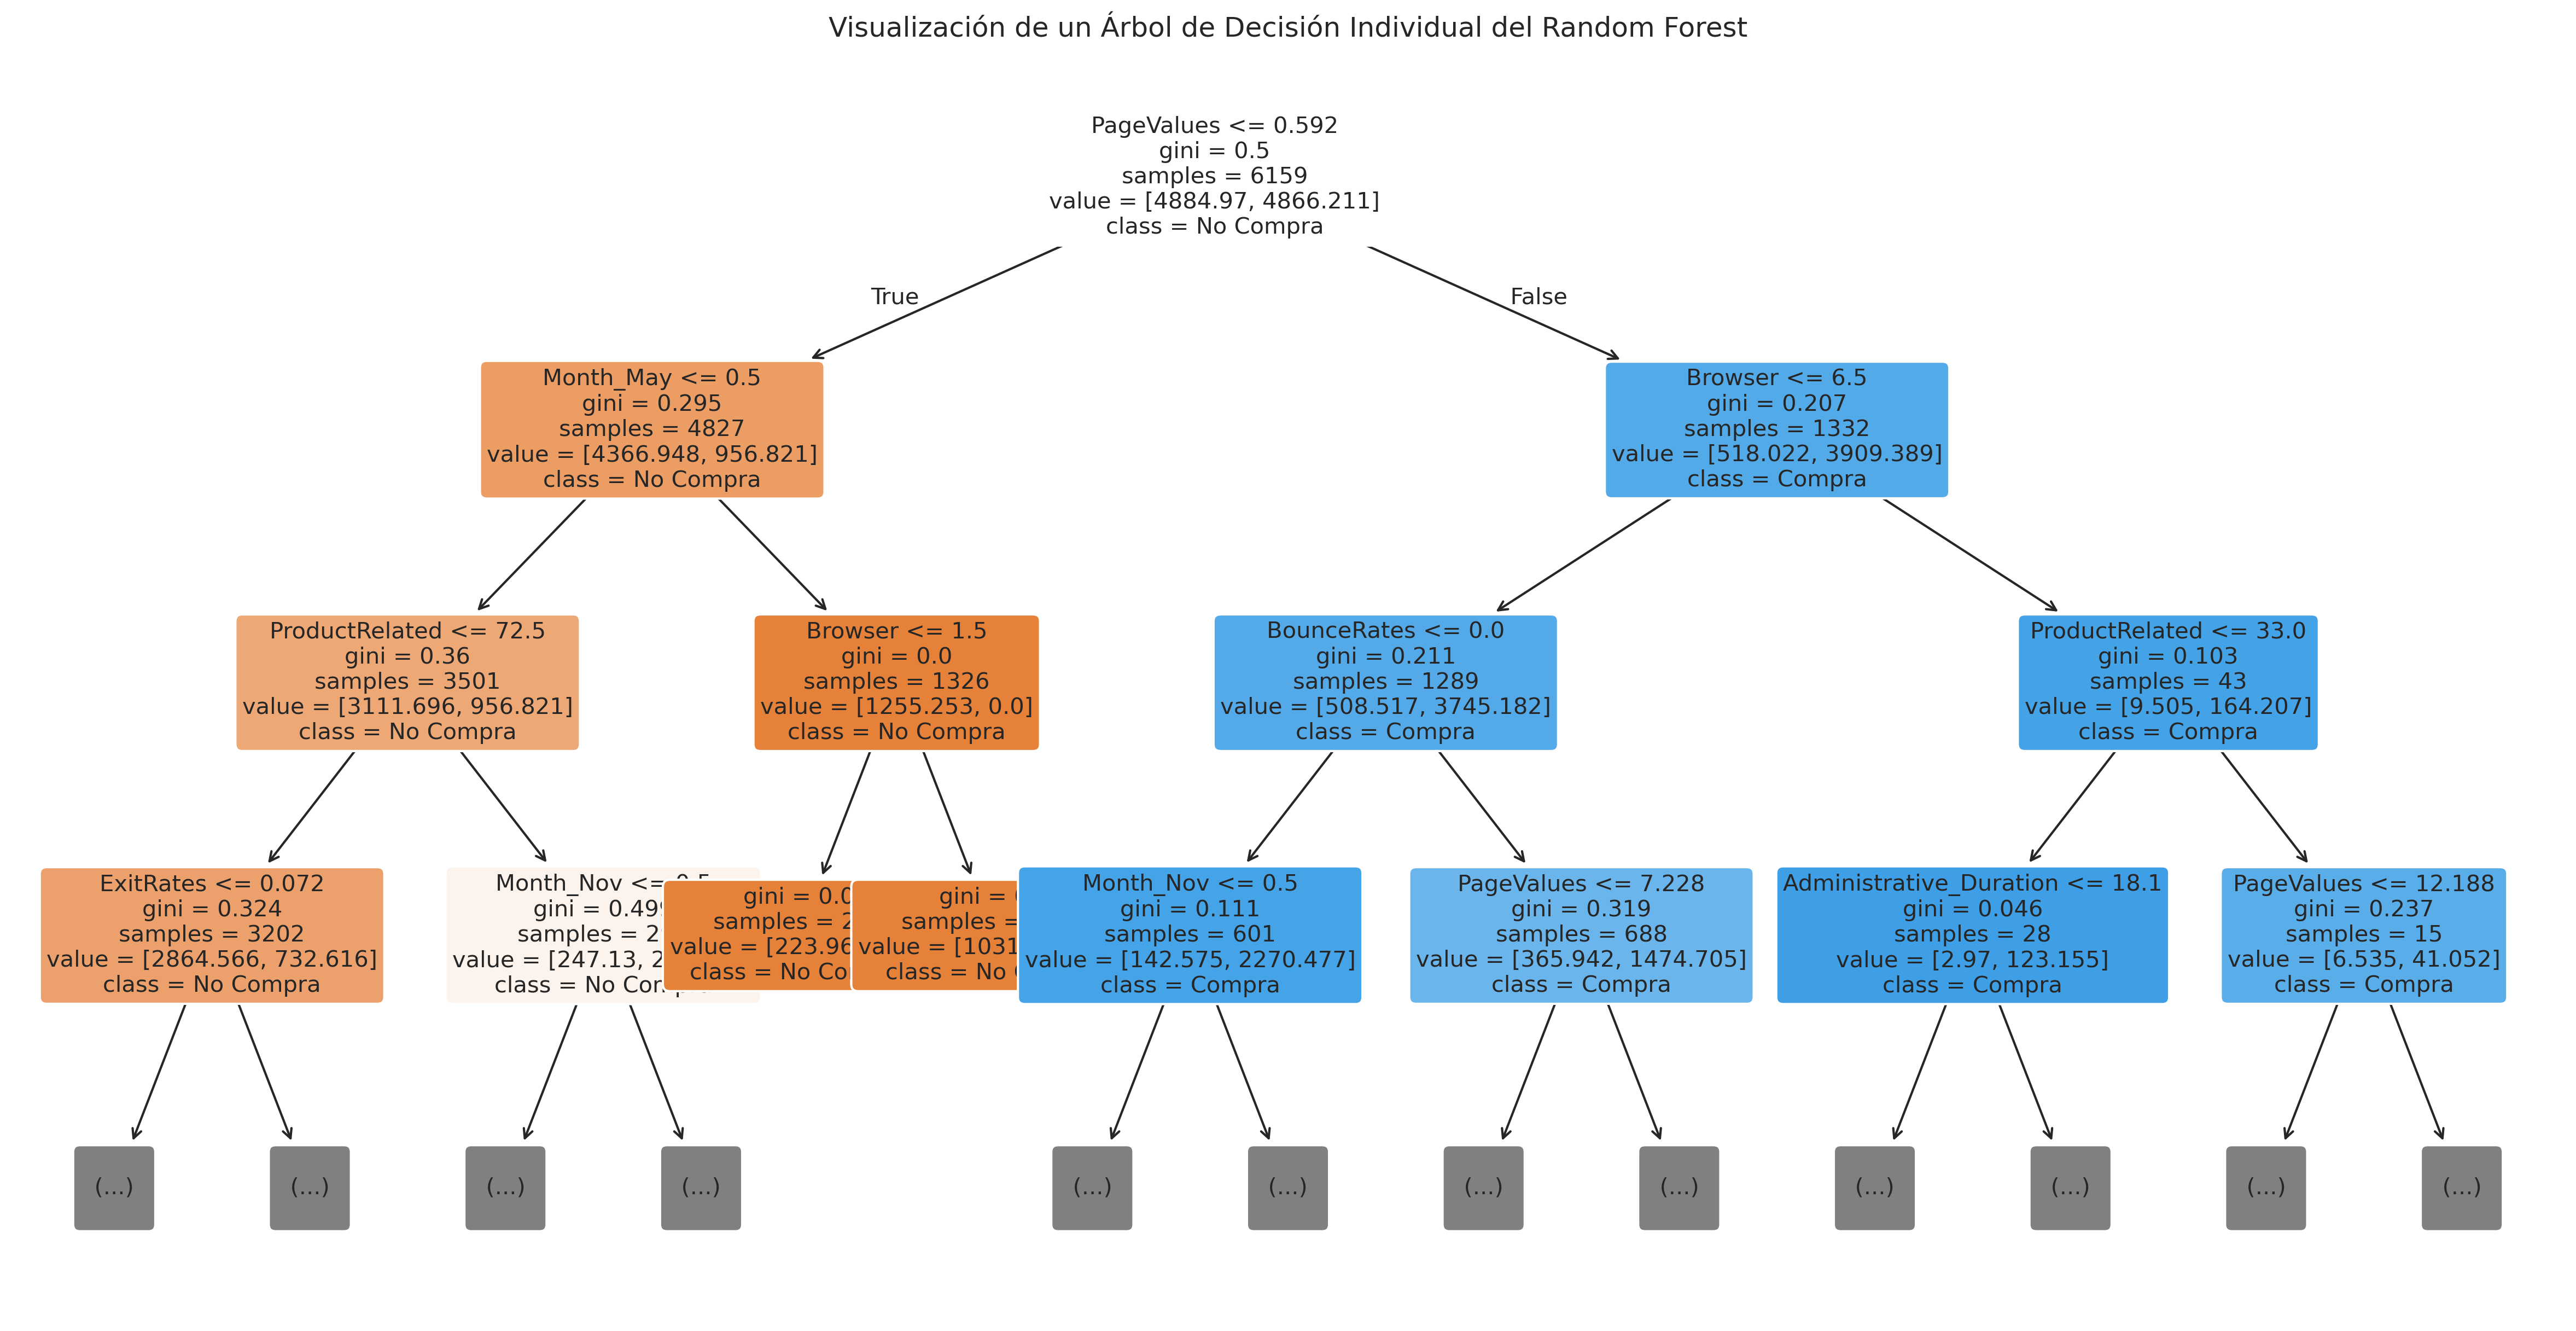

In [45]:
graficiar_arbol_decision_individual(rf_model, X.columns, tree_index=1, max_depth=3)

## **Resultados**

Al analizar el desempeño del modelo Random Forest, se observa un comportamiento distintivo en comparación con la Red Neuronal previamente entrenada:

* Matriz de Confusión: El modelo demuestra una capacidad de separación clara. Al examinar las hojas del árbol de decisión visualizado, se identifican nodos puros correspondientes a la clase "No Compra" (representados en naranja fuerte) y nodos intermedios con predominancia de la clase "Compra" (azul/celeste), lo que evidencia la lógica de clasificación interna del algoritmo.
* Balanceo de Clases: A pesar de que se implementó el parámetro class_weight='balanced', los nodos del árbol (como aquel con Samples: 2731 y Gini: 0.429 ) evidencian que el modelo aún enfrenta desafíos con la pureza debido a la naturaleza intrínseca de los datos. La presencia de un índice Gini de 0.5 en los nodos superiores indica que, en las etapas iniciales de decisión, el modelo opera bajo una incertidumbre máxima (una mezcla 50/50 de las clases ponderadas), comportamiento esperado en la raíz del árbol antes de aplicar las reglas de segmentación.

## **Explicación de Predicciones con Random Forest**

- Para abrir la "caja negra" del Random Forest, utilizamos tres enfoques complementarios: Importancia Global, LIME (Local) y Análisis Estructural de Árboles.

A. Importancia Global (Impureza de Gini)

- El gráfico de barras horizontales confirma que PageValues es la variable dominante. Sin embargo, el Random Forest revela que variables de comportamiento como ProductRelated_Duration y BounceRates tienen un peso secundario mucho más relevante que en la Red Neuronal, actuando como validadores de la intención de compra.

B. Explicación Local con LIME (Local Interpretable Model-agnostic Explanations)

- Como los árboles no son diferenciables (no tienen gradientes), usamos LIME para explicar clientes individuales. LIME genera un modelo lineal local alrededor de un cliente específico para entender qué movió la aguja.
    - Interpretación del Gráfico LIME:
        Barras Verdes (Soportan la clase "Compra"): Para los clientes analizados, valores altos de PageValues son el motor principal de la decisión positiva.
        Barras Rojas (Soportan la clase "No Compra"): Variables como visitar en Mayo (Month_May) o tener una Tasa de Rebote (BounceRates) alta actúan como penalizadores, restando probabilidad de compra.

C. Visualización y Comparativa de Árboles (La "Democracia" del Modelo)

- Esta es la parte medular del algoritmo. Un Random Forest no es un solo experto, es un comité. Hemos extraído y visualizado dos árboles distintos (Estimadores) del bosque para demostrar su diversidad:
    - Árbol #1 (Enfoque en Calidad de Visita):
        - Nodos Críticos: Este árbol prioriza filtros tempranos de "calidad". Observamos un nodo de decisión BounceRates <= 0.029.
        - Lógica: Si el usuario rebota más del 2.9%, este árbol lo descarta inmediatamente. Es un árbol "estricto" que limpia el tráfico basura rápido.
    - Árbol #2 (Enfoque en Interés/Tiempo):
        - Nodos Críticos: Este estimador toma un camino diferente, enfocándose en la regla ProductRelated_Duration < 487.9.
        - Lógica: Aquí el modelo no mira tanto si el usuario "rebota", sino si "se queda". Establece que se necesitan al menos ~8 minutos (488s) de interacción con productos para considerar la compra probable.

- Conclusión de la Comparativa: Mientras el Árbol #1 actúa como un "filtro de seguridad" (eliminando rebotes), el Árbol #2 actúa como un "detector de interés" (midiendo tiempo). La predicción final del modelo es robusta precisamente porque promedia estas visiones complementarias, algo que un solo Árbol de Decisión no podría hacer.

## **Conclusiones**

- Robustez por Diversidad: La visualización de múltiples árboles demuestra que el éxito del Random Forest radica en la descorrelación. Al obligar a distintos árboles a fijarse en distintas variables (unos en BounceRates, otros en Duration), el modelo final es mucho más estable y menos propenso al sobreajuste que un solo árbol de decisión.

- Reglas de Negocio Accionables: Gracias a la explicabilidad del Random Forest, extrajimos umbrales numéricos exactos para el equipo de marketing:
    - *Insight:* Las campañas que atraigan tráfico con una tasa de rebote superior al 2.9% tienen alta probabilidad de no conversión, según lo indica el tercer nodo de decisión del árbol.
    - *Insight:* Para ser considerado un prospecto viable por el modelo, el usuario requiere interactuar al menos 488 segundos con páginas relacionadas con productos.

Comparativa Final: Mientras que en la Red Neuronal (Parte 1) se usó Gradientes Integrados para ver la "sensibilidad" del modelo, aquí LIME permitió ver los "pesos" de la decisión. Ambos métodos coinciden en que PageValues es la variable rey, pero LIME con Random Forest nos dio una visión más clara de cómo las variables negativas (como meses específicos o tasas de salida) actúan como barreras activas para la compra.